In [2]:
# ============================================================
# CELL 1 — Imports & Plotting Settings
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from mplsoccer import Pitch, VerticalPitch

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# ── Project colours (consistent with dash_app/src/config.py) ──
PRIMARY   = "#8a1f33"   # Deep red
SECONDARY = "#1b2838"   # Dark navy
POSITIVE  = "#2ecc71"   # Green
NEGATIVE  = "#e74c3c"   # Red
NEUTRAL   = "#95a5a6"   # Grey
ACCENT    = "#f39c12"   # Amber

# Zone colour-map (light → dark)
ZONE_CMAP = LinearSegmentedColormap.from_list(
    "zone_heat", ["#f0f0f0", "#fdd49e", "#fc8d59", "#d7301f", "#7f0000"]
)

# Plotly defaults
PLOTLY_TEMPLATE = "plotly_white"

# Matplotlib defaults
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "font.size":        10,
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})

# Opta pitch dimensions (for coordinate conversion)
OPTA_X_MAX, OPTA_Y_MAX = 100.0, 100.0
PITCH_LENGTH, PITCH_WIDTH = 105.0, 68.0

print("✅ Imports loaded.")

✅ Imports loaded.


In [3]:
# ============================================================
# CELL 2 — User Input / Match & Team Selection
# ============================================================
# ➡️  EDIT THESE VARIABLES TO CHANGE THE MATCH UNDER ANALYSIS

REPO_ROOT = Path.cwd().parent          # FMP_SerieA_Dashboard/
DATA_ROOT = REPO_ROOT / "data" / "raw"

# ── Season selection ──
SEASON = "2025_2026"                    # e.g. "2024_2025", "2025_2026"

# ── Match file (filename only, without full path) ──
# Leave as None to list available matches and pick interactively.
MATCH_FILE = "30_Fiorentina_Inter_o6xjj7sgpd78ec9y4o77fztg.csv"                       # e.g. "1_Bologna_Udinese_9f9a05us9bdw1ibvqvn1qq49g.csv"

# ── Team to analyse ──
# Leave as None to auto-detect from the match and pick the home team.
TEAM_NAME = "FC Internazionale Milano"                        # e.g. "Bologna FC 1909"

# ── Derived paths ──
EVENTS_DIR = DATA_ROOT / f"serie_a_{SEASON}" / "events"

# ── If MATCH_FILE is None, list available files for convenience ──
if MATCH_FILE is None:
    avail = sorted(EVENTS_DIR.glob("*.csv"))
    print(f"📂 {len(avail)} match files found in serie_a_{SEASON}/events/")
    print("First 15 files:")
    for f in avail[:15]:
        print(f"   {f.name}")
    # Auto-select the first file for quick testing
    MATCH_FILE = avail[0].name
    print(f"\n🔹 Auto-selected: {MATCH_FILE}")

MATCH_PATH = EVENTS_DIR / MATCH_FILE
assert MATCH_PATH.exists(), f"File not found: {MATCH_PATH}"
print(f"\n✅ Match file: {MATCH_PATH.name}")


✅ Match file: 30_Fiorentina_Inter_o6xjj7sgpd78ec9y4o77fztg.csv


In [4]:
# ============================================================
# CELL 3 — Data Loading & Preprocessing
# ============================================================

# ── Helper: flexible column finder ──
def find_col(df, candidates, required=True):
    """
    Find the first matching column from a list of candidates.
    Handles small naming variations (case, underscores, spaces).
    """
    cols_lower = {c.lower().replace(" ", "_").replace("-", "_"): c for c in df.columns}
    for cand in candidates:
        key = cand.lower().replace(" ", "_").replace("-", "_")
        if key in cols_lower:
            return cols_lower[key]
    if required:
        raise KeyError(f"None of {candidates} found in columns")
    return None

# ── Load raw match data ──
raw = pd.read_csv(MATCH_PATH, low_memory=False)
print(f"Loaded {len(raw)} rows, {len(raw.columns)} columns.")

# ── Standardise key column names ──
COL_MAP = {
    find_col(raw, ["event", "event_type", "eventType"]): "event_type",
    find_col(raw, ["type_id", "typeId", "event_type_id"]): "type_id",
    find_col(raw, ["period_id", "periodId", "period"]): "period",
    find_col(raw, ["time_min", "timeMin", "minute", "min"]): "minute",
    find_col(raw, ["time_sec", "timeSec", "second", "sec"]): "second",
    find_col(raw, ["team_name", "teamName", "team"]): "team",
    find_col(raw, ["player_name", "playerName", "player"]): "player",
    find_col(raw, ["x"]): "x",
    find_col(raw, ["y"]): "y",
    find_col(raw, ["outcome"]): "outcome",
}

# Optional columns
for cands, alias in [
    (["Pass End X", "pass_end_x", "passEndX"], "pass_end_x"),
    (["Pass End Y", "pass_end_y", "passEndY"], "pass_end_y"),
    (["event_id", "eventId"], "event_id"),
    (["match_id", "matchId"], "match_id"),
    (["Related event ID", "related_event_id"], "related_event_id"),
    (["Length", "length", "pass_length"], "pass_length"),
    (["Angle", "angle", "pass_angle"], "pass_angle"),
]:
    found = find_col(raw, cands, required=False)
    if found:
        COL_MAP[found] = alias

df = raw.rename(columns=COL_MAP).copy()

# ── Qualifier flag columns (kept as boolean) ──
QUAL_FLAGS = [
    "Long ball", "Cross", "Head pass", "Through ball",
    "Free kick taken", "Corner taken", "Goal Kick",
    "Throw In", "Attacking Pass", "Keeper Throw",
    "Chipped", "Launch", "Lay-off", "Switch of play",
    "Pull Back", "GK hoof", "Gk kick from hands",
    "Set piece", "From corner", "Free kick", "Fast break",
    "Big Chance", "Leading to attempt", "Leading to goal",
    "Assisted", "Intentional Assist", "own goal",
    "Penalty", "Goal disallowed", "Blocked",
    "Head", "Right footed", "Left footed", "Volley",
    "1 on 1", "Individual Play",
]
for qf in QUAL_FLAGS:
    if qf in df.columns:
        df[qf] = df[qf].notna()
    else:
        df[qf] = False

# ── Filter to in-play periods (1 = 1st half, 2 = 2nd half, 3+ = extra time) ──
df = df[df["period"].isin([1, 2, 3, 4, 5])].copy()

# ── Numeric safety ──
for c in ["minute", "second", "x", "y", "pass_end_x", "pass_end_y", "type_id", "outcome"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# ── Sort events chronologically ──
sort_cols = ["period", "minute", "second"]
if "event_id" in df.columns:
    sort_cols.append("event_id")
df = df.sort_values(sort_cols).reset_index(drop=True)

# ── Build absolute match time (seconds from kick-off) ──
# Each period starts at 0:00 in the raw data, so we offset:
#   Period 1 → +0, Period 2 → +45*60, Period 3 → +90*60, etc.
PERIOD_OFFSETS = {1: 0, 2: 45*60, 3: 90*60, 4: 105*60, 5: 120*60}
df["abs_time"] = (
    df["period"].map(PERIOD_OFFSETS).fillna(0)
    + df["minute"] * 60
    + df["second"]
)

# ── Normalise attacking direction (all attacks left → right) ──
# Opta convention: Period 1 home attacks right, away attacks left.
# We flip so that EVERY team always attacks left→right (x=0 own goal, x=100 opp goal).
teams = df["team"].dropna().unique()
assert len(teams) == 2, f"Expected 2 teams, found {len(teams)}: {teams}"

# Detect home team from team_position if available
tp_col = find_col(df, ["team_position", "teamPosition", "home_away"], required=False)
if tp_col and tp_col in df.columns:
    home_mask = df[tp_col].astype(str).str.lower().str.contains("home")
    home_team = df.loc[home_mask, "team"].dropna().unique()
    away_team = df.loc[~home_mask, "team"].dropna().unique()
    HOME_TEAM = home_team[0] if len(home_team) > 0 else teams[0]
    AWAY_TEAM = away_team[0] if len(away_team) > 0 else teams[1]
else:
    # Fallback: parse from filename (Home_Away)
    HOME_TEAM, AWAY_TEAM = teams[0], teams[1]

# For direction normalisation: use median shot x per team in period 1 to detect direction.
SHOT_TYPE_IDS = [13, 14, 15, 16]  # Miss, Post, Saved Shot, Goal
for team_name in teams:
    p1_shots = df[(df["team"] == team_name) & (df["period"] == 1) & (df["type_id"].isin(SHOT_TYPE_IDS))]
    # If a team shoots toward x < 50 in period 1, their coordinates need flipping.
    if len(p1_shots) > 0 and p1_shots["x"].median() < 50:
        # This team attacks right→left in period 1 → flip periods 1, 3, 5
        mask_odd = (df["team"] == team_name) & (df["period"].isin([1, 3, 5]))
        mask_even = (df["team"] == team_name) & (df["period"].isin([2, 4]))
    else:
        # This team attacks left→right in period 1 → flip periods 2, 4
        mask_odd = pd.Series(False, index=df.index)
        mask_even = (df["team"] == team_name) & (df["period"].isin([2, 4]))
    
    flip_mask = mask_odd | mask_even
    df.loc[flip_mask, "x"] = OPTA_X_MAX - df.loc[flip_mask, "x"]
    df.loc[flip_mask, "y"] = OPTA_Y_MAX - df.loc[flip_mask, "y"]
    if "pass_end_x" in df.columns:
        df.loc[flip_mask, "pass_end_x"] = OPTA_X_MAX - df.loc[flip_mask, "pass_end_x"]
    if "pass_end_y" in df.columns:
        df.loc[flip_mask, "pass_end_y"] = OPTA_Y_MAX - df.loc[flip_mask, "pass_end_y"]

# ── Team selection ──
if TEAM_NAME is None:
    TEAM_NAME = HOME_TEAM
    print(f"🏠 Auto-selected HOME team: {TEAM_NAME}")

OPP_TEAM = [t for t in teams if t != TEAM_NAME][0]
print(f"\n⚽ Match: {HOME_TEAM} vs {AWAY_TEAM}")
print(f"📊 Analysing: {TEAM_NAME}")
print(f"👥 Opponent: {OPP_TEAM}")
print(f"📋 Events after preprocessing: {len(df)}")

Loaded 1715 rows, 248 columns.

⚽ Match: ACF Fiorentina vs FC Internazionale Milano
📊 Analysing: FC Internazionale Milano
👥 Opponent: ACF Fiorentina
📋 Events after preprocessing: 1708


In [5]:
# ============================================================
# CELL 4 — Helper Functions
# ============================================================

# ── Event type helpers ──
SHOT_TYPE_IDS = [13, 14, 15, 16]    # Miss, Post, Saved Shot, Goal
PASS_TYPE_ID  = 1
TACKLE_ID     = 7
INTERCEPTION_ID = 8
CLEARANCE_ID  = 12
BALL_RECOVERY_ID = 49
TAKE_ON_ID    = 3
FOUL_ID       = 4
AERIAL_ID     = 44
DISPOSSESSED_ID = 50

# Events that indicate meaningful on-ball actions (for possession logic)
ACTION_TYPE_IDS = [
    PASS_TYPE_ID, 2,  # Pass, Offside pass
    TAKE_ON_ID, FOUL_ID, TACKLE_ID, INTERCEPTION_ID,
    CLEARANCE_ID, *SHOT_TYPE_IDS,
    AERIAL_ID, BALL_RECOVERY_ID, DISPOSSESSED_ID,
    52, 61, 74,  # Keeper pick-up, Ball touch, Blocked pass
]

# Events that signal dead-ball / possession break
DEAD_BALL_EVENTS = {"Out", "End", "Start", "Foul", "Card",
                    "Offside provoked", "Referee Drop Ball",
                    "Start delay", "End delay"}

def is_pass(row):
    return row["type_id"] == PASS_TYPE_ID

def is_shot(row_or_series):
    if isinstance(row_or_series, pd.Series):
        return row_or_series["type_id"].isin(SHOT_TYPE_IDS)
    return row_or_series["type_id"] in SHOT_TYPE_IDS

def is_goal(row):
    return row["type_id"] == 16 and not row.get("Goal disallowed", False)

def is_goal_kick(row):
    """Goal kick = Pass with Goal Kick qualifier."""
    return row["type_id"] == PASS_TYPE_ID and row.get("Goal Kick", False)


def simple_xg(x, y):
    """
    Distance-based xG proxy (same as 03_attacking_phase notebook).
    Uses Opta 0-100 coordinates, goal at (100, 50).
    Returns a value in [0, ~0.76].
    
    NOTE: This is a rough approximation, NOT a calibrated xG model.
    """
    dx = (100 - x) * (PITCH_LENGTH / 100)
    dy = (50 - y) * (PITCH_WIDTH / 100)
    dist = np.sqrt(dx**2 + dy**2)
    return 0.76 * np.exp(-0.12 * dist)


def outcome_colour(label):
    """Return green for positive outcomes, red for negative."""
    return POSITIVE if "✅" in label or "positive" in label.lower() else NEGATIVE


print("✅ Helper functions loaded.")

✅ Helper functions loaded.


In [6]:
# ============================================================
# CELL 5 — Possession & Timestamp Construction
# ============================================================
#
# POSSESSION DEFINITION
# ---------------------
# A possession is a continuous sequence of events by the same team.
# A new possession starts when:
#   (a) the team on the ball changes (opponent performs a meaningful action)
#   (b) a dead-ball event occurs (foul, out, end of period)
#   (c) there is a gap > MAX_GAP_SECONDS between consecutive actions
#       by the same team (handles data gaps / long pauses)
#
# Limitations:
# - This is an EVENT-DATA APPROXIMATION of possession.
# - Actual ball possession may differ (e.g. contested aerials).
# - Short "transitional" moments may be grouped into the wrong possession.

MAX_GAP_SECONDS = 25.0  # Max gap within same possession

# ── Filter to action events only ──
actions = df[df["type_id"].isin(ACTION_TYPE_IDS)].copy()
actions = actions.dropna(subset=["team", "x", "y"])
actions = actions.sort_values(["period", "minute", "second",
                               "event_id" if "event_id" in actions.columns else "abs_time"
                              ]).reset_index(drop=True)

# ── Build possession IDs ──
poss_id = 0
poss_ids = []
prev_team = None
prev_time = -999
prev_period = -1

for _, row in actions.iterrows():
    team = row["team"]
    t = row["abs_time"]
    p = row["period"]
    
    # New possession if: different team, different period, or large time gap
    if (team != prev_team) or (p != prev_period) or (t - prev_time > MAX_GAP_SECONDS):
        poss_id += 1
    
    poss_ids.append(poss_id)
    prev_team = team
    prev_time = t
    prev_period = p

actions["poss_id"] = poss_ids

# ── Tag possessions with owning team ──
poss_team = actions.groupby("poss_id")["team"].first().rename("poss_team")
actions = actions.merge(poss_team, on="poss_id", how="left")

# ── Possession summary table ──
poss_summary = (
    actions.groupby("poss_id")
    .agg(
        team=("poss_team", "first"),
        n_events=("event_type", "count"),
        start_time=("abs_time", "min"),
        end_time=("abs_time", "max"),
        start_x=("x", "first"),
        max_x=("x", "max"),
        has_shot=("type_id", lambda s: s.isin(SHOT_TYPE_IDS).any()),
        has_goal=("type_id", lambda s: (s == 16).any()),
    )
    .reset_index()
)
poss_summary["duration"] = poss_summary["end_time"] - poss_summary["start_time"]
poss_summary["reached_final_third"] = poss_summary["max_x"] >= 66.67
poss_summary["reached_box"] = poss_summary["max_x"] >= 83.33

# ── Stats ──
team_poss = poss_summary[poss_summary["team"] == TEAM_NAME]
opp_poss  = poss_summary[poss_summary["team"] == OPP_TEAM]

print(f"Total possessions detected: {len(poss_summary)}")
print(f"  {TEAM_NAME}: {len(team_poss)} possessions")
print(f"  {OPP_TEAM}: {len(opp_poss)} possessions")
print(f"\n  {TEAM_NAME} reaching final third: {team_poss['reached_final_third'].sum()} / {len(team_poss)} = {team_poss['reached_final_third'].mean():.0%}")
print(f"  {TEAM_NAME} with a shot: {team_poss['has_shot'].sum()} / {len(team_poss)} = {team_poss['has_shot'].mean():.0%}")

Total possessions detected: 438
  FC Internazionale Milano: 226 possessions
  ACF Fiorentina: 212 possessions

  FC Internazionale Milano reaching final third: 95 / 226 = 42%
  FC Internazionale Milano with a shot: 11 / 226 = 5%


In [7]:
# ============================================================
# CELL 6 — 18-Zone Pitch Mapping Helpers
# ============================================================
#
# Classic 18-zone pitch: 6 longitudinal bands × 3 lateral lanes
#
# Zone numbering (attacking left → right):
#
#  Left flank   |  Z4  |  Z7  |  Z10 |  Z13 |  Z16 |  Z18* |
#  Centre       |  Z5  |  Z8  |  Z11 |  Z14 |  Z17 |  Z18* |
#  Right flank  |  Z6  |  Z9  |  Z12 |  Z15 |  Z18*|  Z18* |
#               | Def  | Def- | Mid  | Att- | Pre- | Final |
#               |      | Mid  |      | Mid  | Final|       |
#
# *Note: The box area is treated specially in some analyses.
#
# X boundaries (Opta 0-100): 0, 16.67, 33.33, 50, 66.67, 83.33, 100
# Y boundaries (Opta 0-100): 0, 33.33, 66.67, 100
#
# In Opta coords: y=0 is traditionally the RIGHT side of the pitch
# when attacking left→right, y=100 is the LEFT side.

X_BOUNDS = [0, 16.67, 33.33, 50.0, 66.67, 83.33, 100.0]
Y_BOUNDS = [0, 33.33, 66.67, 100.0]

# Zone labels: row index = x-band (0..5), col index = y-lane (0..2)
# y-lane 0 = y<33.33 = RIGHT flank (Opta convention)
# y-lane 1 = 33.33≤y<66.67 = CENTRE
# y-lane 2 = y≥66.67 = LEFT flank
ZONE_LABELS = [
    ["Z6",  "Z5",  "Z4" ],   # x-band 0: Defensive
    ["Z9",  "Z8",  "Z7" ],   # x-band 1: Def-Midfield
    ["Z12", "Z11", "Z10"],   # x-band 2: Midfield
    ["Z15", "Z14", "Z13"],   # x-band 3: Att-Midfield
    ["Z18", "Z17", "Z16"],   # x-band 4: Pre-Final Third
    ["Z18", "Z17", "Z16"],   # x-band 5: Final Third (shares labels with band 4 for 18-zone)
]

# More descriptive 18-zone layout with unique labels
ZONE_GRID = np.array([
    [ 6,  5,  4],  # Defensive
    [ 9,  8,  7],  # Def-Mid
    [12, 11, 10],  # Mid
    [15, 14, 13],  # Att-Mid
    [18, 17, 16],  # Final Third (outer)
    [18, 17, 16],  # Final Third (inner / box)
])

# For a proper 18-zone model we use 6 x-bands × 3 y-lanes = 18 zones
# Zone numbering: row-major from defensive-right
ZONE_NAMES = {
    1: "Def Right",    2: "Def Centre",   3: "Def Left",
    4: "DM Right",     5: "DM Centre",    6: "DM Left",
    7: "Mid Right",    8: "Mid Centre",   9: "Mid Left",
    10: "AM Right",   11: "AM Centre",   12: "AM Left",
    13: "FT Right",   14: "FT Centre (Z14)", 15: "FT Left",
    16: "Box Right",  17: "Box Centre",  18: "Box Left",
}


def assign_zone(x, y):
    """
    Assign an event to one of 18 pitch zones based on Opta coordinates.
    Returns zone number 1..18.
    
    Grid layout (6 x-bands × 3 y-lanes):
      x-band: [0,16.67), [16.67,33.33), [33.33,50), [50,66.67), [66.67,83.33), [83.33,100]
      y-lane: [0,33.33) = Right, [33.33,66.67) = Centre, [66.67,100] = Left
    """
    # Clamp to valid range
    x = np.clip(x, 0, 100)
    y = np.clip(y, 0, 100)
    
    # X-band (0..5)
    xb = min(int(x / 16.667), 5)
    # Y-lane (0=Right, 1=Centre, 2=Left)
    yl = min(int(y / 33.334), 2)
    
    # Zone number: row-major, 1-indexed
    # Right=col0, Centre=col1, Left=col2
    zone = xb * 3 + yl + 1
    return zone


def assign_zone_vectorized(x_series, y_series):
    """Vectorized version of assign_zone."""
    x = np.clip(x_series.values, 0, 100)
    y = np.clip(y_series.values, 0, 100)
    xb = np.minimum((x / 16.667).astype(int), 5)
    yl = np.minimum((y / 33.334).astype(int), 2)
    return xb * 3 + yl + 1


def assign_lane(y):
    """Classify y-coordinate into Right / Centre / Left lane."""
    if y < 33.33:
        return "Right"
    elif y < 66.67:
        return "Centre"
    else:
        return "Left"


def assign_lane_vectorized(y_series):
    """Vectorized lane assignment."""
    return pd.cut(
        y_series, bins=[-0.1, 33.33, 66.67, 100.1],
        labels=["Right", "Centre", "Left"]
    )


# ── Apply zones to the actions dataframe ──
actions["zone"] = assign_zone_vectorized(actions["x"], actions["y"])
actions["lane"] = assign_lane_vectorized(actions["y"])

# Also assign zone for pass endpoints
if "pass_end_x" in actions.columns and "pass_end_y" in actions.columns:
    mask_pass = actions["type_id"] == PASS_TYPE_ID
    valid_end = mask_pass & actions["pass_end_x"].notna() & actions["pass_end_y"].notna()
    actions.loc[valid_end, "end_zone"] = assign_zone_vectorized(
        actions.loc[valid_end, "pass_end_x"],
        actions.loc[valid_end, "pass_end_y"]
    )
    actions.loc[valid_end, "end_lane"] = assign_lane_vectorized(
        actions.loc[valid_end, "pass_end_y"]
    )


# ── Pitch drawing helper ──
def draw_18_zone_pitch(ax, zone_values, title="", cmap=ZONE_CMAP, vmax=None,
                        show_pct=False, total=None, label_fmt="{:.0f}",
                        show_zone_names=True):
    """
    Draw a football pitch with 18 coloured zones on a matplotlib Axes.
    
    Parameters
    ----------
    ax : matplotlib Axes (should already have a pitch drawn via mplsoccer)
    zone_values : dict {zone_number: value} — values to display/colour
    title : str
    show_pct : bool — if True, show percentage instead of raw count
    total : float — denominator for percentage calculation
    """
    if vmax is None:
        vmax = max(zone_values.values()) if zone_values else 1
    if vmax == 0:
        vmax = 1
    
    # mplsoccer "opta" pitch: x in [0,100], y in [0,100]
    for zone_num in range(1, 19):
        xb = (zone_num - 1) // 3   # 0..5
        yl = (zone_num - 1) % 3    # 0=Right, 1=Centre, 2=Left
        
        x0 = X_BOUNDS[xb]
        x1 = X_BOUNDS[xb + 1]
        y0 = Y_BOUNDS[yl]
        y1 = Y_BOUNDS[yl + 1]
        
        val = zone_values.get(zone_num, 0)
        intensity = val / vmax if vmax > 0 else 0
        colour = cmap(intensity)
        
        rect = mpatches.FancyBboxPatch(
            (x0, y0), x1 - x0, y1 - y0,
            boxstyle="round,pad=0.3",
            facecolor=colour, edgecolor="white", linewidth=1.2,
            alpha=0.70, zorder=1
        )
        ax.add_patch(rect)
        
        # Label
        cx = (x0 + x1) / 2
        cy = (y0 + y1) / 2
        
        if show_pct and total and total > 0:
            txt = f"{val / total:.0%}"
        else:
            txt = label_fmt.format(val)
        
        if val > 0:
            ax.text(cx, cy + 2, txt, ha="center", va="center",
                    fontsize=9, fontweight="bold", color="black", zorder=5)
        
        if show_zone_names:
            short = ZONE_NAMES.get(zone_num, f"Z{zone_num}").split(" ")[-1]
            if zone_num <= 3:
                short = "DEF\n" + short
            ax.text(cx, cy - 4, f"Z{zone_num}", ha="center", va="center",
                    fontsize=6, color="grey", alpha=0.7, zorder=5)
    
    if title:
        ax.set_title(title, fontsize=13, fontweight="bold", pad=10)


print(f"✅ Zone mapping ready. {len(actions)} action events with zones assigned.")
print(f"   Zone distribution (top 5):")
print(actions[actions["poss_team"] == TEAM_NAME]["zone"].value_counts().head().to_string())

✅ Zone mapping ready. 1473 action events with zones assigned.
   Zone distribution (top 5):
zone
6     73
13    72
10    63
7     58
11    57


In [8]:
# ============================================================
# CELL 7 — Offensive Moment: Definitions & Shared Logic
# ============================================================
#
# OFFENSIVE MOMENT = structured possession by the selected team.
#
# We define three sub-phases within the offensive moment:
#   1. BUILD-UP — starts from a goal kick, covers the first phase
#   2. REACHING FINAL THIRD — any event that enters x ≥ 66.67
#   3. CHANCE CREATION — possessions that produce shots or big chances
#
# ──────────────────────────────────────────────────────────────
# THRESHOLDS & RULES
# ──────────────────────────────────────────────────────────────

FINAL_THIRD_X   = 66.67   # x >= this = final third
BOX_X           = 83.33   # x >= this = penalty box area
BUILDUP_WINDOW  = 25.0    # seconds after goal kick to track
COUNTER_WINDOW  = 15.0    # seconds to check if opponent exploits turnover

# ── Team actions & possessions ──
team_actions = actions[actions["poss_team"] == TEAM_NAME].copy()
opp_actions  = actions[actions["poss_team"] == OPP_TEAM].copy()

team_poss_ids = team_actions["poss_id"].unique()
print(f"{TEAM_NAME}: {len(team_poss_ids)} offensive possessions, {len(team_actions)} actions")


# ──────────────────────────────────────────────────────────────
# BUILD-UP DETECTION
# ──────────────────────────────────────────────────────────────
# Rule: build-up starts with a GOAL KICK (Pass + Goal Kick qualifier)
# by the selected team.
#
# Build-up END conditions (whichever comes first):
#   (a) Ball reaches final third (x >= 66.67)
#   (b) Possession is lost (team changes)
#   (c) 25 seconds elapsed from the goal kick
#   (d) A set piece interrupts the sequence

goal_kicks = team_actions[
    (team_actions["type_id"] == PASS_TYPE_ID) &
    (team_actions["Goal Kick"] == True)
].copy()

print(f"Goal kicks by {TEAM_NAME}: {len(goal_kicks)}")

# ── For each goal kick, extract the build-up sequence ──
buildup_sequences = []

for idx, gk in goal_kicks.iterrows():
    gk_time = gk["abs_time"]
    gk_poss = gk["poss_id"]
    gk_period = gk["period"]
    
    # All events within same possession, within 25s window
    window = actions[
        (actions["poss_id"] == gk_poss) &
        (actions["abs_time"] >= gk_time) &
        (actions["abs_time"] <= gk_time + BUILDUP_WINDOW)
    ].copy()
    
    if len(window) == 0:
        continue
    
    window["gk_idx"] = idx
    window["gk_time"] = gk_time
    window["time_from_gk"] = window["abs_time"] - gk_time
    
    # ── Classify: short or long goal kick ──
    if gk.get("Long ball", False):
        window["gk_type"] = "Long"
    else:
        # Short if pass length < 30 or end_x < 35
        end_x = gk.get("pass_end_x", np.nan)
        p_len = gk.get("pass_length", np.nan)
        if (pd.notna(p_len) and p_len < 32) or (pd.notna(end_x) and end_x < 35):
            window["gk_type"] = "Short"
        else:
            window["gk_type"] = "Long"
    
    # ── Direction: where does the first non-GK pass go? ──
    non_gk = window.iloc[1:] if len(window) > 1 else window
    if "pass_end_y" in non_gk.columns and non_gk["pass_end_y"].notna().any():
        first_end_y = non_gk["pass_end_y"].dropna().iloc[0] if non_gk["pass_end_y"].notna().any() else gk["y"]
    else:
        first_end_y = non_gk["y"].iloc[0] if len(non_gk) > 0 else gk["y"]
    window["gk_direction"] = assign_lane(first_end_y)
    
    # ── Determine outcome ──
    reached_ft = (window["x"] >= FINAL_THIRD_X).any()
    has_shot_in_window = window["type_id"].isin(SHOT_TYPE_IDS).any()
    has_sot = (
        (window["type_id"].isin([15, 16])).any()  # Saved Shot or Goal
    )
    
    # Check what happens after this possession ends
    poss_end_time = window["abs_time"].max()
    
    # Did the team keep possession until end of window?
    next_events = actions[
        (actions["abs_time"] > poss_end_time) &
        (actions["abs_time"] <= poss_end_time + 2) &
        (actions["period"] == gk_period)
    ]
    lost_ball = False
    if len(next_events) > 0:
        next_team = next_events.iloc[0]["team"]
        if next_team == OPP_TEAM:
            lost_ball = True
    
    # Also check: if no further team events in the same possession after window
    full_poss = actions[actions["poss_id"] == gk_poss]
    if full_poss["team"].iloc[-1] != TEAM_NAME:
        lost_ball = True
    
    # Negative: opponent box entry / shot within COUNTER_WINDOW after loss
    opp_counter = False
    opp_shot_after = False
    if lost_ball:
        opp_after = actions[
            (actions["team"] == OPP_TEAM) &
            (actions["abs_time"] > poss_end_time) &
            (actions["abs_time"] <= poss_end_time + COUNTER_WINDOW) &
            (actions["period"] == gk_period)
        ]
        if len(opp_after) > 0:
            opp_counter = (opp_after["x"] >= BOX_X).any()
            opp_shot_after = opp_after["type_id"].isin(SHOT_TYPE_IDS).any()
    
    # Assign outcome label
    if has_sot:
        outcome = "✅ Shot on target"
    elif has_shot_in_window:
        outcome = "✅ Shot created"
    elif reached_ft and not lost_ball:
        outcome = "✅ Reached final third"
    elif not lost_ball:
        outcome = "✅ Kept possession"
    elif lost_ball and opp_shot_after:
        outcome = "❌ Lost → opponent shot"
    elif lost_ball and opp_counter:
        outcome = "❌ Lost → opponent box entry"
    else:
        outcome = "❌ Lost possession"
    
    window["buildup_outcome"] = outcome
    buildup_sequences.append(window)

if buildup_sequences:
    df_buildup = pd.concat(buildup_sequences, ignore_index=True)
else:
    df_buildup = pd.DataFrame()

print(f"\nBuild-up sequences extracted: {len(goal_kicks)}")


# ──────────────────────────────────────────────────────────────
# FINAL-THIRD ENTRY DETECTION
# ──────────────────────────────────────────────────────────────
# Rule: an event by the team crosses into x >= 66.67.
# For passes, we check pass_end_x. For other actions, we check x.
# We record the FIRST entry per possession.

ft_entries = []

for pid in team_poss_ids:
    poss_events = team_actions[team_actions["poss_id"] == pid].sort_values("abs_time")
    if len(poss_events) == 0:
        continue
    
    prev_in_ft = False
    for i, (ridx, row) in enumerate(poss_events.iterrows()):
        # Check if this action enters final third
        in_ft = row["x"] >= FINAL_THIRD_X
        
        # For passes, also check destination
        if row["type_id"] == PASS_TYPE_ID:
            end_x = row.get("pass_end_x", np.nan)
            if pd.notna(end_x) and end_x >= FINAL_THIRD_X:
                in_ft = True
        
        if in_ft and not prev_in_ft:
            # First entry into final third in this possession
            entry = row.copy()
            
            # Classify entry mechanism
            if row["type_id"] == PASS_TYPE_ID:
                if row.get("Cross", False):
                    entry["entry_method"] = "Cross"
                elif row.get("Through ball", False):
                    entry["entry_method"] = "Through ball"
                elif row.get("Long ball", False):
                    entry["entry_method"] = "Long/Direct pass"
                elif row.get("Switch of play", False):
                    entry["entry_method"] = "Switch of play"
                else:
                    entry["entry_method"] = "Short pass progression"
            elif row["type_id"] == BALL_RECOVERY_ID:
                entry["entry_method"] = "Ball recovery"
            elif row["type_id"] == TAKE_ON_ID:
                entry["entry_method"] = "Dribble/Take-on"
            elif row["type_id"] == INTERCEPTION_ID:
                entry["entry_method"] = "Interception"
            else:
                entry["entry_method"] = "Other"
            
            # What happens next in this possession after entry?
            remaining = poss_events.iloc[i+1:]
            entry["entered_box"] = (remaining["x"] >= BOX_X).any() if len(remaining) > 0 else False
            entry["shot_after"] = remaining["type_id"].isin(SHOT_TYPE_IDS).any() if len(remaining) > 0 else False
            entry["goal_after"] = (remaining["type_id"] == 16).any() if len(remaining) > 0 else False
            
            # Check if possession stayed forward or circled back
            if len(remaining) > 0:
                next_team_x = remaining[remaining["team"] == TEAM_NAME]["x"]
                entry["stayed_forward"] = (next_team_x >= 50).all() if len(next_team_x) > 0 else False
            else:
                entry["stayed_forward"] = False
            
            ft_entries.append(entry)
            break  # Only first entry per possession
        
        prev_in_ft = in_ft

if ft_entries:
    df_ft_entry = pd.DataFrame(ft_entries)
else:
    df_ft_entry = pd.DataFrame()

print(f"\nFinal-third entries detected: {len(df_ft_entry)}")
print(f"  = {len(df_ft_entry)}/{len(team_poss_ids)} possessions ({len(df_ft_entry)/max(len(team_poss_ids),1):.0%})")


# ──────────────────────────────────────────────────────────────
# CHANCE CREATION DETECTION
# ──────────────────────────────────────────────────────────────
# Rule: a "chance" = a shot event (type_id in [13,14,15,16])
# within a team possession.
# We also tag the KEY PASS (last pass before the shot in the same
# possession) to classify chance origin.

team_shots = team_actions[team_actions["type_id"].isin(SHOT_TYPE_IDS)].copy()

# xG calculation
team_shots["xG"] = team_shots.apply(lambda r: simple_xg(r["x"], r["y"]), axis=1)

# Shot location
team_shots["shot_location"] = np.where(
    team_shots["x"] >= BOX_X, "Inside box",
    np.where(team_shots["x"] >= FINAL_THIRD_X, "Edge of box / Outside", "Long range")
)

# Shot result
team_shots["shot_result"] = team_shots["type_id"].map({
    16: "Goal", 15: "Saved", 13: "Miss", 14: "Post"
})
team_shots["on_target"] = team_shots["type_id"].isin([15, 16])

# ── Identify key pass before each shot ──
chance_origins = []

for _, shot in team_shots.iterrows():
    pid = shot["poss_id"]
    shot_time = shot["abs_time"]
    
    # Find last pass by same team before this shot in same possession
    prev_passes = team_actions[
        (team_actions["poss_id"] == pid) &
        (team_actions["type_id"] == PASS_TYPE_ID) &
        (team_actions["abs_time"] < shot_time)
    ]
    
    origin = "Unassisted / Individual"
    key_passer = None
    
    if len(prev_passes) > 0:
        last_pass = prev_passes.iloc[-1]
        key_passer = last_pass["player"]
        
        if last_pass.get("Cross", False):
            origin = "Cross"
        elif last_pass.get("Pull Back", False):
            origin = "Cutback"
        elif last_pass.get("Through ball", False):
            origin = "Through ball"
        elif last_pass.get("Long ball", False):
            origin = "Long ball"
        elif last_pass.get("Free kick taken", False) or last_pass.get("Corner taken", False):
            origin = "Set piece delivery"
        elif last_pass.get("Lay-off", False):
            origin = "Lay-off"
        else:
            origin = "Central / frontal pass"
    
    # Check for set-piece context
    poss_events = team_actions[team_actions["poss_id"] == pid]
    if poss_events["Free kick taken"].any() or poss_events["Corner taken"].any():
        if origin == "Unassisted / Individual":
            origin = "Set piece (direct)"
        elif origin not in ["Set piece delivery"]:
            pass  # keep the more specific label
    
    if shot.get("Penalty", False):
        origin = "Penalty"
    
    chance_origins.append({
        "poss_id": pid,
        "origin": origin,
        "key_passer": key_passer,
    })

if chance_origins:
    df_origins = pd.DataFrame(chance_origins)
    team_shots = team_shots.reset_index(drop=True)
    df_origins = df_origins.reset_index(drop=True)
    team_shots = pd.concat([team_shots, df_origins[["origin", "key_passer"]]], axis=1)

print(f"\nChances (shots) by {TEAM_NAME}: {len(team_shots)}")
print(f"  Total xG: {team_shots['xG'].sum():.2f}")
print(f"  Goals: {(team_shots['type_id'] == 16).sum()}")

print("\n✅ Offensive moment definitions ready.")

FC Internazionale Milano: 226 offensive possessions, 827 actions
Goal kicks by FC Internazionale Milano: 7

Build-up sequences extracted: 7

Final-third entries detected: 105
  = 105/226 possessions (46%)

Chances (shots) by FC Internazionale Milano: 12
  Total xG: 0.94
  Goals: 1

✅ Offensive moment definitions ready.


---

## Sub-Phase 1: Build-up

**Definition:** The build-up phase begins with every **goal kick** by the selected team. We track all actions within the same possession for up to **25 seconds** after the goal kick.

**Build-up ends when:**
- The ball reaches the final third (x ≥ 66.67)
- Possession is lost (opponent gains control)
- 25 seconds elapse from the goal kick

**Positive outcomes:** ✅ Kept possession · Reached final third · Created shot · Shot on target  
**Negative outcomes:** ❌ Lost possession · Lost → opponent box entry (15s) · Lost → opponent shot (15s)

---

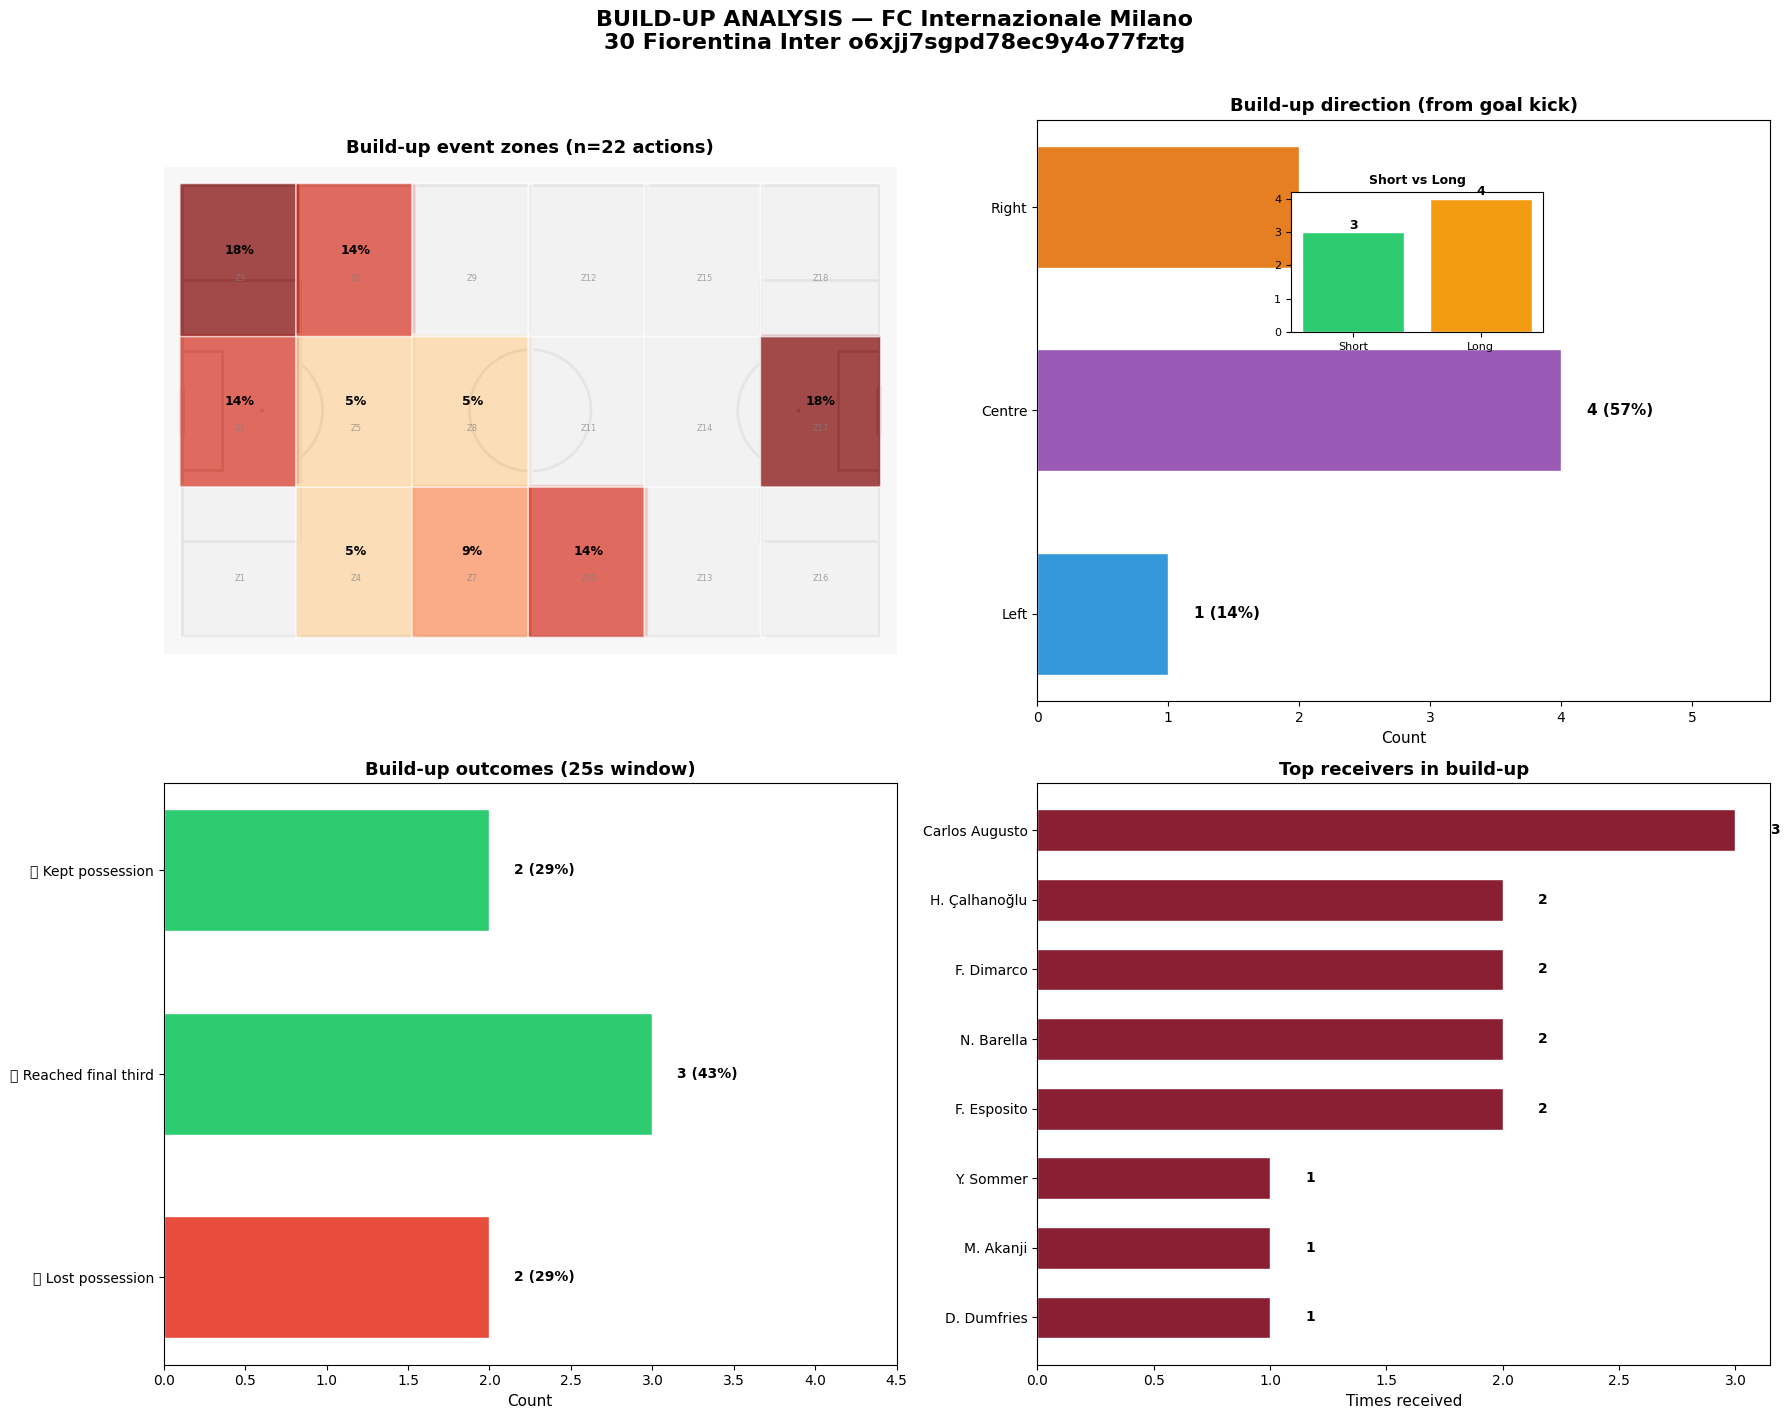


  BUILD-UP SUMMARY — FC Internazionale Milano
  Total build-ups (goal kicks): 7
  Short: 3  |  Long: 4
  Direction → Left: 1 | Centre: 4 | Right: 2

  POSITIVE outcomes: 5 / 7 = 71%
  NEGATIVE outcomes: 2 / 7 = 29%


In [9]:
# ============================================================
# CELL 8 — SUB-PHASE 1 OUTPUT: BUILD-UP
# ============================================================

if len(df_buildup) == 0:
    print("⚠️ No build-up sequences found (no goal kicks by this team in this match).")
else:
    # ── Summary per build-up sequence ──
    bu_summary = (
        df_buildup.groupby("gk_idx")
        .agg(
            gk_type=("gk_type", "first"),
            direction=("gk_direction", "first"),
            outcome=("buildup_outcome", "first"),
            n_events=("event_type", "count"),
            max_x=("x", "max"),
            duration=("time_from_gk", "max"),
        )
        .reset_index()
    )
    n_bu = len(bu_summary)
    
    # ── Figure: 2×2 layout ──
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    fig.suptitle(
        f"BUILD-UP ANALYSIS — {TEAM_NAME}\n"
        f"{MATCH_FILE.replace('.csv', '').replace('_', ' ')}",
        fontsize=16, fontweight="bold", y=1.01
    )
    
    # ──────────────────────────────────────────
    # PLOT 1: Zone heatmap — where build-up develops
    # ──────────────────────────────────────────
    ax1 = axes[0, 0]
    pitch1 = Pitch(pitch_type="opta", pitch_color="#f7f7f7", line_color="#cccccc")
    pitch1.draw(ax=ax1)
    
    # Count events per zone during build-up
    bu_zone_counts = df_buildup["zone"].value_counts().to_dict()
    draw_18_zone_pitch(ax1, bu_zone_counts,
                       title=f"Build-up event zones (n={len(df_buildup)} actions)",
                       show_pct=True, total=len(df_buildup))
    
    # ──────────────────────────────────────────
    # PLOT 2: Direction chart — Right / Centre / Left
    # ──────────────────────────────────────────
    ax2 = axes[0, 1]
    dir_counts = bu_summary["direction"].value_counts()
    dir_order = ["Left", "Centre", "Right"]
    dir_vals = [dir_counts.get(d, 0) for d in dir_order]
    dir_colors = ["#3498db", "#9b59b6", "#e67e22"]
    
    bars = ax2.barh(dir_order, dir_vals, color=dir_colors, edgecolor="white", height=0.6)
    for bar, val in zip(bars, dir_vals):
        pct = val / max(n_bu, 1) * 100
        ax2.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f"{val} ({pct:.0f}%)", va="center", fontsize=11, fontweight="bold")
    ax2.set_title("Build-up direction (from goal kick)", fontsize=13, fontweight="bold")
    ax2.set_xlabel("Count")
    ax2.set_xlim(0, max(dir_vals) * 1.4 if dir_vals else 5)
    
    # ── Short vs Long bar (separate small figure to avoid axis conflict) ──
    type_counts = bu_summary["gk_type"].value_counts()
    inset = fig.add_axes([0.72, 0.78, 0.14, 0.10])  # [left, bottom, width, height] in figure coords
    t_labels = ["Short", "Long"]
    t_vals = [type_counts.get(l, 0) for l in t_labels]
    inset.bar([0, 1], t_vals, color=[POSITIVE, ACCENT], edgecolor="white")
    inset.set_xticks([0, 1])
    inset.set_xticklabels(t_labels)
    for i, v in enumerate(t_vals):
        inset.text(i, v + 0.1, str(v), ha="center", fontsize=9, fontweight="bold")
    inset.set_title("Short vs Long", fontsize=9, fontweight="bold")
    inset.set_ylabel("")
    inset.tick_params(labelsize=8)
    
    # ──────────────────────────────────────────
    # PLOT 3: Outcomes — traffic light (green/red)
    # ──────────────────────────────────────────
    ax3 = axes[1, 0]
    outcome_counts = bu_summary["outcome"].value_counts().sort_index()
    oc_labels = outcome_counts.index.tolist()
    oc_vals = outcome_counts.values
    oc_colors = [POSITIVE if "✅" in l else NEGATIVE for l in oc_labels]
    
    bars3 = ax3.barh(range(len(oc_labels)), oc_vals, color=oc_colors,
                     edgecolor="white", height=0.6)
    ax3.set_yticks(range(len(oc_labels)))
    ax3.set_yticklabels(oc_labels, fontsize=10)
    for bar, val in zip(bars3, oc_vals):
        pct = val / max(n_bu, 1) * 100
        ax3.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
                 f"{val} ({pct:.0f}%)", va="center", fontsize=10, fontweight="bold")
    ax3.set_title("Build-up outcomes (25s window)", fontsize=13, fontweight="bold")
    ax3.set_xlabel("Count")
    ax3.set_xlim(0, max(oc_vals) * 1.5 if len(oc_vals) > 0 else 5)
    ax3.invert_yaxis()
    
    # ──────────────────────────────────────────
    # PLOT 4: Top receivers in build-up
    # ──────────────────────────────────────────
    ax4 = axes[1, 1]
    
    # Receivers = players who receive a pass during build-up (exclude the GK who takes the goal kick)
    bu_passes = df_buildup[
        (df_buildup["type_id"] == PASS_TYPE_ID) &
        (df_buildup["outcome"] == 1)
    ]
    # The receiver of a pass = the next player to touch the ball
    # Approximation: for each successful pass, the next action's player is the receiver
    receivers = []
    for gk_idx_val in df_buildup["gk_idx"].unique():
        seq = df_buildup[df_buildup["gk_idx"] == gk_idx_val].sort_values("abs_time")
        for i in range(len(seq) - 1):
            if seq.iloc[i]["type_id"] == PASS_TYPE_ID and seq.iloc[i]["outcome"] == 1:
                receivers.append({
                    "receiver": seq.iloc[i + 1]["player"],
                    "zone": seq.iloc[i + 1]["zone"],
                    "lane": seq.iloc[i + 1].get("lane", "Unknown"),
                })
    
    if receivers:
        df_recv = pd.DataFrame(receivers)
        top_recv = df_recv["receiver"].value_counts().head(8)
        bars4 = ax4.barh(top_recv.index[::-1], top_recv.values[::-1],
                         color=PRIMARY, edgecolor="white", height=0.6)
        for bar, val in zip(bars4, top_recv.values[::-1]):
            ax4.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
                     str(val), va="center", fontsize=10, fontweight="bold")
        ax4.set_title("Top receivers in build-up", fontsize=13, fontweight="bold")
        ax4.set_xlabel("Times received")
    else:
        ax4.text(0.5, 0.5, "No receiver data", ha="center", va="center",
                 transform=ax4.transAxes, fontsize=12)
        ax4.set_title("Top receivers in build-up", fontsize=13, fontweight="bold")
    
    plt.tight_layout()
    plt.show()
    
    # ── Summary table ──
    print("\n" + "="*60)
    print(f"  BUILD-UP SUMMARY — {TEAM_NAME}")
    print("="*60)
    print(f"  Total build-ups (goal kicks): {n_bu}")
    print(f"  Short: {type_counts.get('Short', 0)}  |  Long: {type_counts.get('Long', 0)}")
    print(f"  Direction → Left: {dir_counts.get('Left',0)} | Centre: {dir_counts.get('Centre',0)} | Right: {dir_counts.get('Right',0)}")
    print(f"\n  POSITIVE outcomes: {sum(1 for o in bu_summary['outcome'] if '✅' in o)} / {n_bu} = {sum(1 for o in bu_summary['outcome'] if '✅' in o)/max(n_bu,1):.0%}")
    print(f"  NEGATIVE outcomes: {sum(1 for o in bu_summary['outcome'] if '❌' in o)} / {n_bu} = {sum(1 for o in bu_summary['outcome'] if '❌' in o)/max(n_bu,1):.0%}")
    print("="*60)

---

## Sub-Phase 2: Reaching Final Third

**Definition:** An event is considered a "final-third entry" when the ball first crosses x ≥ 66.67 within a team possession (one entry per possession).

**Entry method** is classified by the event type that triggers the entry:  
Short pass progression · Long/Direct pass · Through ball · Cross · Switch of play · Ball recovery · Dribble/Take-on · Other

**Z14** = Central pre-final-third zone (x ∈ [66.67, 83.33], y ∈ [33.33, 66.67]) — a critical creative zone.

---

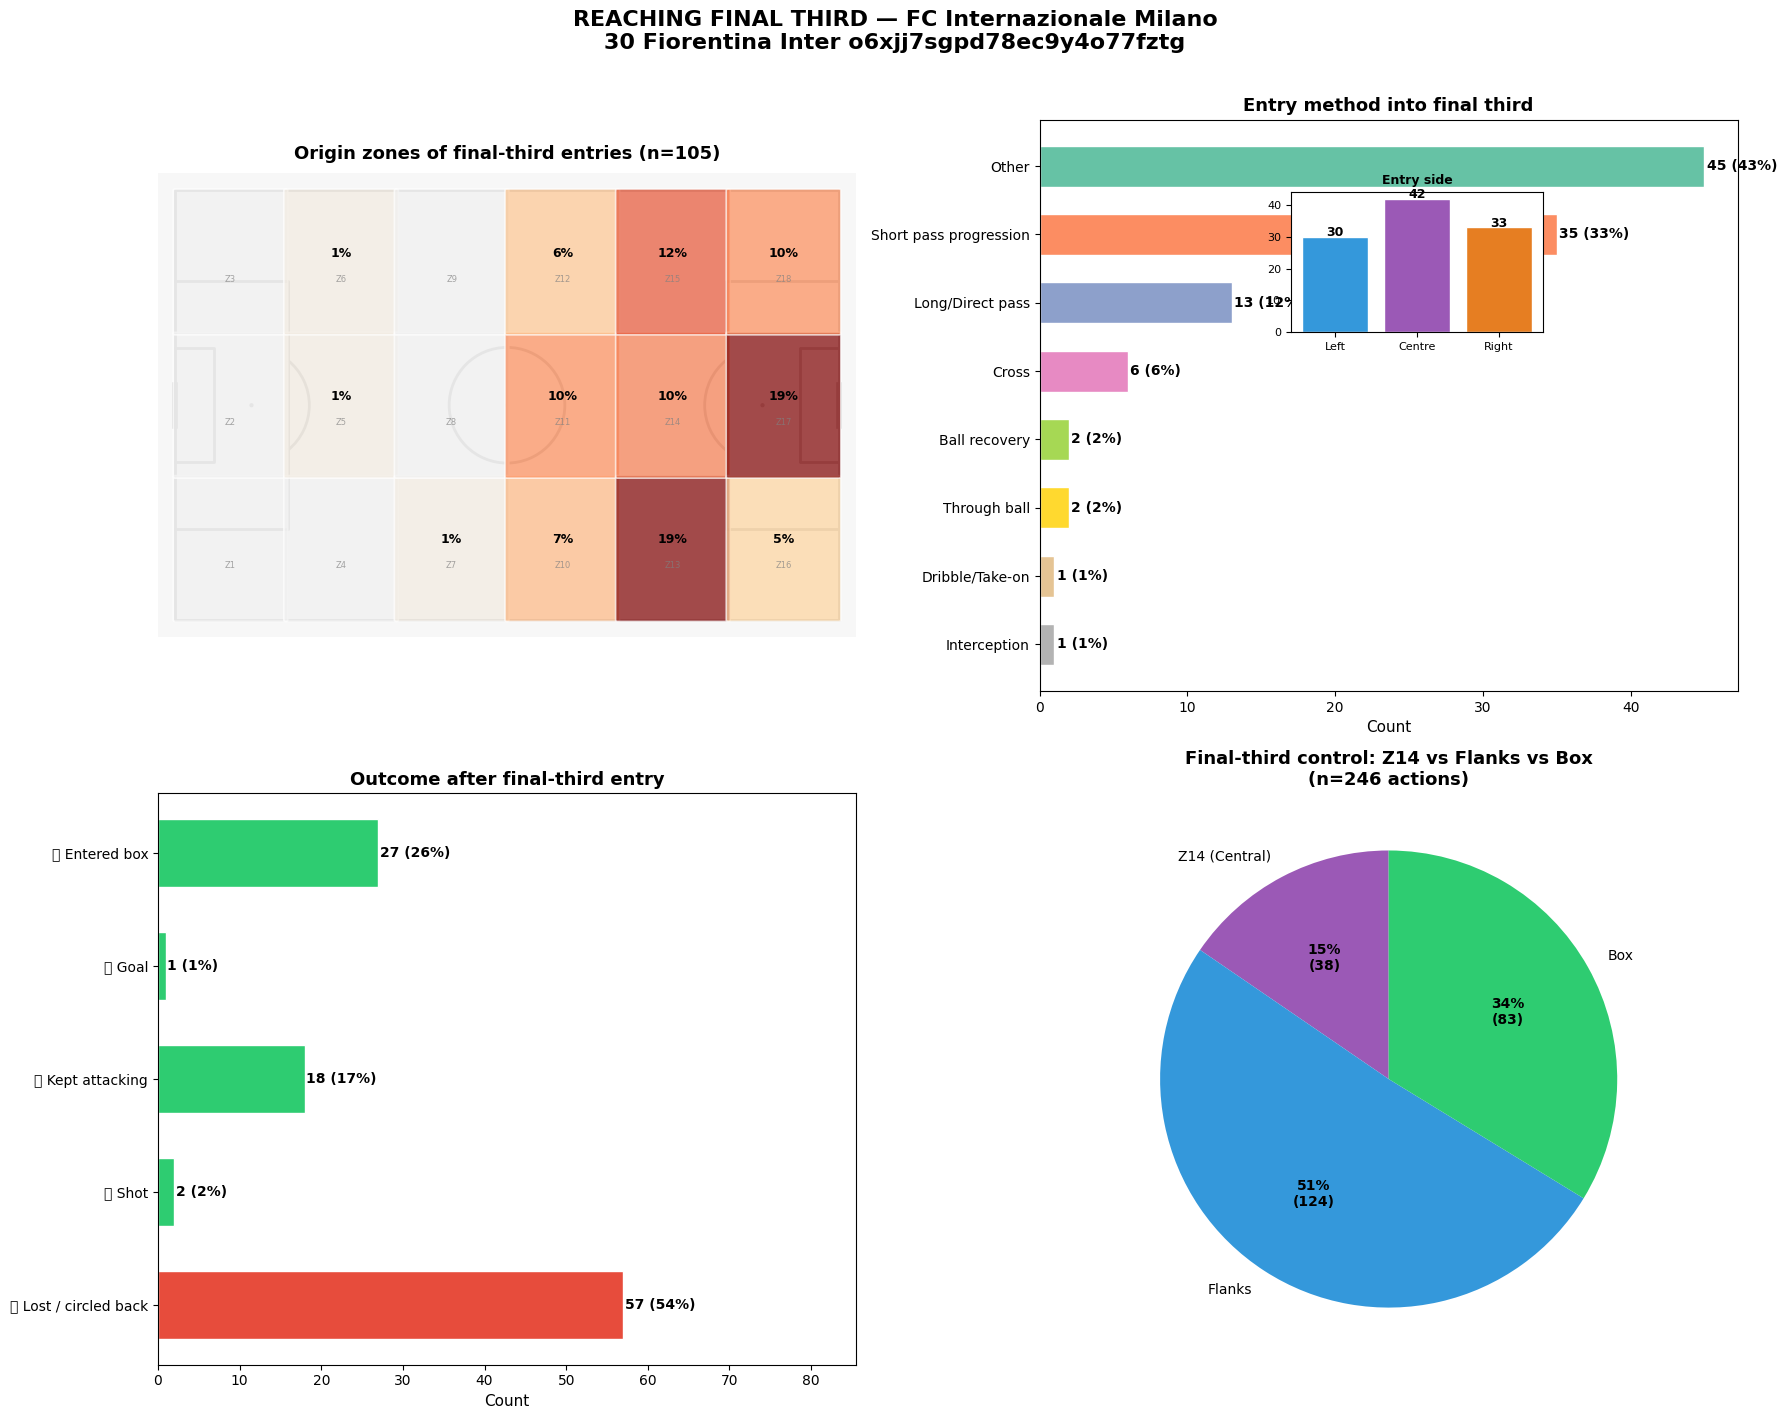


  FINAL THIRD ENTRY SUMMARY — FC Internazionale Milano
  Possessions: 226
  Reaching final third: 105 (46%)
  Entry side → Left: 30 | Centre: 42 | Right: 33

  Top entry method: Other (45)
  Z14 actions: 38 | Flank actions: 125 | Box actions: 83

  POSITIVE outcomes after entry: 48 (46%)
  NEGATIVE outcomes after entry: 57 (54%)


In [11]:
# ============================================================
# CELL 9 — SUB-PHASE 2 OUTPUT: REACHING FINAL THIRD
# ============================================================

# Matplotlib-compatible qualitative palette (replaces px.colors.qualitative.Set2)
_MPL_SET2 = ["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3",
             "#a6d854", "#ffd92f", "#e5c494", "#b3b3b3"]

if len(df_ft_entry) == 0:
    print("⚠️ No final-third entries found.")
else:
    n_ft = len(df_ft_entry)
    n_total_poss = len(team_poss_ids)
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    fig.suptitle(
        f"REACHING FINAL THIRD — {TEAM_NAME}\n"
        f"{MATCH_FILE.replace('.csv', '').replace('_', ' ')}",
        fontsize=16, fontweight="bold", y=1.01
    )
    
    # ──────────────────────────────────────────
    # PLOT 1: Pitch — origin zones of FT entries
    # ──────────────────────────────────────────
    ax1 = axes[0, 0]
    pitch1 = Pitch(pitch_type="opta", pitch_color="#f7f7f7", line_color="#cccccc")
    pitch1.draw(ax=ax1)
    
    # Zone of the event that triggers FT entry
    ft_zone_counts = df_ft_entry["zone"].value_counts().to_dict()
    draw_18_zone_pitch(ax1, ft_zone_counts,
                       title=f"Origin zones of final-third entries (n={n_ft})",
                       show_pct=True, total=n_ft)
    
    # ──────────────────────────────────────────
    # PLOT 2: Entry route — side distribution + method
    # ──────────────────────────────────────────
    ax2 = axes[0, 1]
    
    # Entry lane (where the entry event happens in y)
    lane_counts = df_ft_entry["lane"].value_counts()
    lane_order = ["Left", "Centre", "Right"]
    lane_vals = [lane_counts.get(d, 0) for d in lane_order]
    
    # Entry method
    method_counts = df_ft_entry["entry_method"].value_counts()
    methods = method_counts.index.tolist()
    method_colors = _MPL_SET2[:len(methods)]
    
    bars_m = ax2.barh(methods[::-1], method_counts.values[::-1],
                      color=method_colors[:len(methods)][::-1],
                      edgecolor="white", height=0.6)
    for bar, val in zip(bars_m, method_counts.values[::-1]):
        pct = val / max(n_ft, 1) * 100
        ax2.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
                 f"{val} ({pct:.0f}%)", va="center", fontsize=10, fontweight="bold")
    ax2.set_title("Entry method into final third", fontsize=13, fontweight="bold")
    ax2.set_xlabel("Count")
    
    # Lane inset (using fig.add_axes to avoid axis type conflict)
    inset2 = fig.add_axes([0.72, 0.78, 0.14, 0.10])
    lane_colors = ["#3498db", "#9b59b6", "#e67e22"]
    inset2.bar([0, 1, 2], lane_vals, color=lane_colors, edgecolor="white")
    inset2.set_xticks([0, 1, 2])
    inset2.set_xticklabels(lane_order)
    for i, v in enumerate(lane_vals):
        inset2.text(i, v + 0.1, f"{v}", ha="center", fontsize=9, fontweight="bold")
    inset2.set_title("Entry side", fontsize=9, fontweight="bold")
    inset2.tick_params(labelsize=8)
    
    # ──────────────────────────────────────────
    # PLOT 3: What happens after FT entry
    # ──────────────────────────────────────────
    ax3 = axes[1, 0]
    
    outcomes_ft = []
    for _, row in df_ft_entry.iterrows():
        if row.get("goal_after", False):
            outcomes_ft.append("✅ Goal")
        elif row.get("shot_after", False):
            outcomes_ft.append("✅ Shot")
        elif row.get("entered_box", False):
            outcomes_ft.append("✅ Entered box")
        elif row.get("stayed_forward", False):
            outcomes_ft.append("✅ Kept attacking")
        else:
            outcomes_ft.append("❌ Lost / circled back")
    
    df_ft_entry["ft_outcome"] = outcomes_ft
    oc_ft = pd.Series(outcomes_ft).value_counts().sort_index()
    oc_labels_ft = oc_ft.index.tolist()
    oc_vals_ft = oc_ft.values
    oc_colors_ft = [POSITIVE if "✅" in l else NEGATIVE for l in oc_labels_ft]
    
    bars3 = ax3.barh(range(len(oc_labels_ft)), oc_vals_ft, color=oc_colors_ft,
                     edgecolor="white", height=0.6)
    ax3.set_yticks(range(len(oc_labels_ft)))
    ax3.set_yticklabels(oc_labels_ft, fontsize=10)
    for bar, val in zip(bars3, oc_vals_ft):
        pct = val / max(n_ft, 1) * 100
        ax3.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
                 f"{val} ({pct:.0f}%)", va="center", fontsize=10, fontweight="bold")
    ax3.set_title("Outcome after final-third entry", fontsize=13, fontweight="bold")
    ax3.set_xlabel("Count")
    ax3.set_xlim(0, max(oc_vals_ft) * 1.5 if len(oc_vals_ft) > 0 else 5)
    ax3.invert_yaxis()
    
    # ──────────────────────────────────────────
    # PLOT 4: Z14 vs Flanks — heatmap of FT actions
    # ──────────────────────────────────────────
    ax4 = axes[1, 1]
    
    # Get all team actions in the final third
    ft_actions = team_actions[team_actions["x"] >= FINAL_THIRD_X].copy()
    ft_actions["ft_area"] = "Flanks"
    # Z14 proxy: x in [66.67, 83.33] and y in [33.33, 66.67]
    z14_mask = (
        (ft_actions["x"] >= FINAL_THIRD_X) & (ft_actions["x"] < BOX_X) &
        (ft_actions["y"] >= 33.33) & (ft_actions["y"] < 66.67)
    )
    box_mask = ft_actions["x"] >= BOX_X
    flank_mask = ~z14_mask & ~box_mask
    
    ft_actions.loc[z14_mask, "ft_area"] = "Z14 (Central)"
    ft_actions.loc[box_mask, "ft_area"] = "Box"
    ft_actions.loc[flank_mask, "ft_area"] = "Flanks"
    
    area_counts = ft_actions["ft_area"].value_counts()
    area_order = ["Z14 (Central)", "Flanks", "Box"]
    area_vals = [area_counts.get(a, 0) for a in area_order]
    area_colors = ["#9b59b6", "#3498db", POSITIVE]
    
    # Filter out zero-value slices to avoid matplotlib warnings
    non_zero = [(lbl, v, c) for lbl, v, c in zip(area_order, area_vals, area_colors) if v > 0]
    if non_zero:
        nz_labels, nz_vals, nz_colors = zip(*non_zero)
        wedges, texts, autotexts = ax4.pie(
            nz_vals, labels=nz_labels, colors=nz_colors,
            autopct=lambda p: f"{p:.0f}%\n({int(p*sum(nz_vals)/100)})",
            startangle=90, textprops={"fontsize": 10}
        )
        for at in autotexts:
            at.set_fontweight("bold")
    ax4.set_title(
        f"Final-third control: Z14 vs Flanks vs Box\n(n={len(ft_actions)} actions)",
        fontsize=13, fontweight="bold"
    )
    
    plt.tight_layout()
    plt.show()
    
    # ── Summary ──
    print("\n" + "="*60)
    print(f"  FINAL THIRD ENTRY SUMMARY — {TEAM_NAME}")
    print("="*60)
    print(f"  Possessions: {n_total_poss}")
    print(f"  Reaching final third: {n_ft} ({n_ft/max(n_total_poss,1):.0%})")
    print(f"  Entry side → Left: {lane_counts.get('Left',0)} | Centre: {lane_counts.get('Centre',0)} | Right: {lane_counts.get('Right',0)}")
    print(f"\n  Top entry method: {method_counts.index[0]} ({method_counts.values[0]})")
    print(f"  Z14 actions: {area_counts.get('Z14 (Central)', 0)} | Flank actions: {area_counts.get('Flanks', 0)} | Box actions: {area_counts.get('Box', 0)}")
    pos_ft = sum(1 for o in outcomes_ft if "✅" in o)
    neg_ft = sum(1 for o in outcomes_ft if "❌" in o)
    print(f"\n  POSITIVE outcomes after entry: {pos_ft} ({pos_ft/max(n_ft,1):.0%})")
    print(f"  NEGATIVE outcomes after entry: {neg_ft} ({neg_ft/max(n_ft,1):.0%})")
    print("="*60)

---

## Sub-Phase 3: Chance Creation

**Definition:** A chance is defined as a **shot event** (Miss, Post, Saved Shot, Goal) produced by the team within their offensive possessions.

**Chance origin** is classified by the **key pass** (last pass before the shot in the same possession):  
Cross · Through ball · Central/frontal pass · Long ball · Cutback · Set piece delivery · Lay-off · Penalty · Unassisted/Individual

**xG** is a distance-based approximation (not a calibrated model). Use for relative comparison only.

---

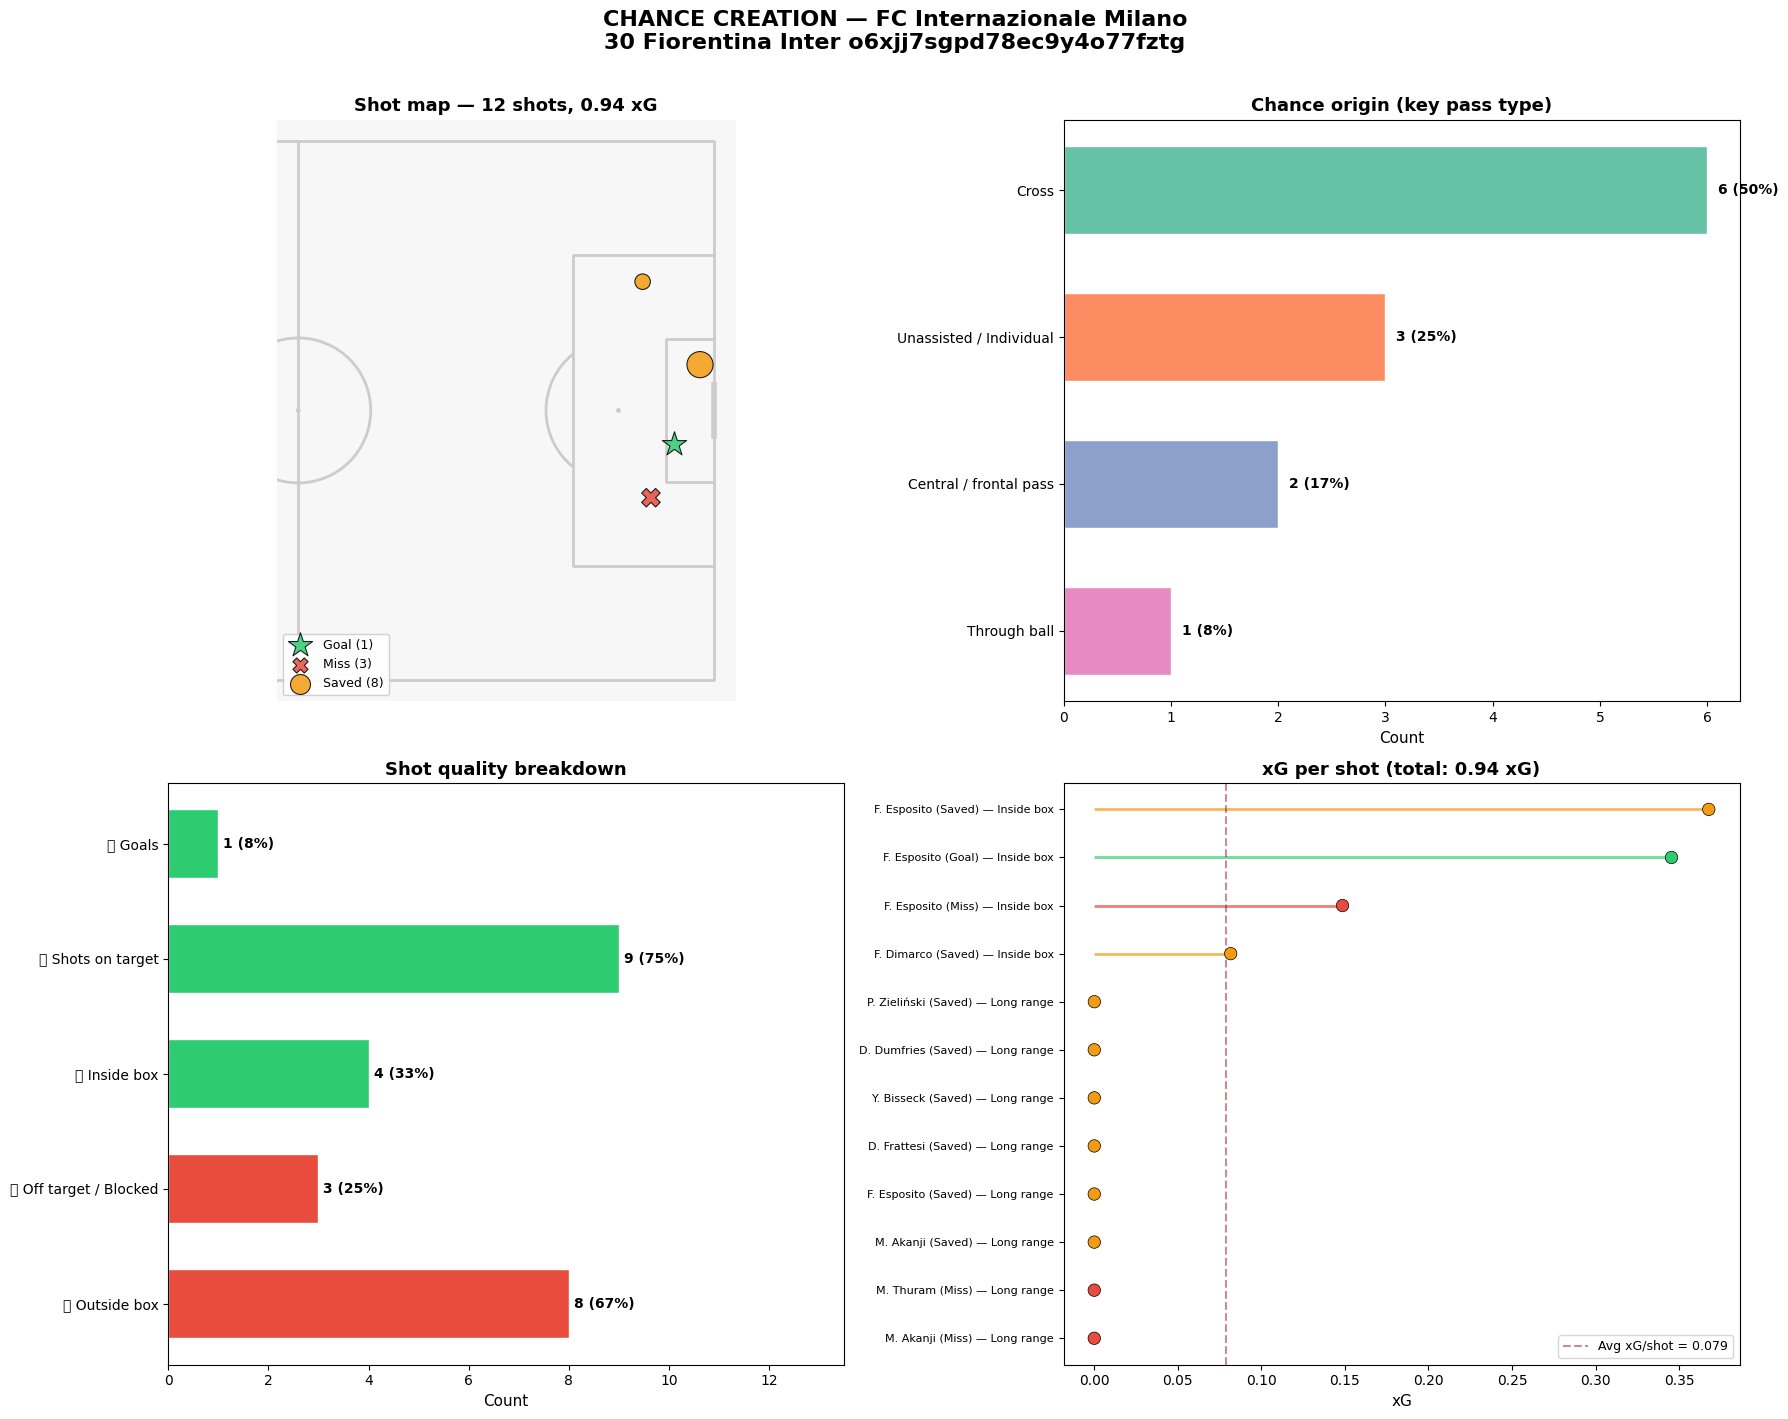


  CHANCE CREATION SUMMARY — FC Internazionale Milano
  Total possessions: 226
  Possessions with shot: 11 (5%)
  Total shots: 12
  Goals: 1
  Shots on target: 9 (75%)
  Inside box: 4 (33%)
  Total xG: 0.94
  xG per shot: 0.079
  xG per possession: 0.004

  Top origin: Cross (6 shots)
  Top chance creator: N. Barella (5 key passes)


In [12]:
# ============================================================
# CELL 10 — SUB-PHASE 3 OUTPUT: CHANCE CREATION
# ============================================================

# Matplotlib-compatible qualitative palette
_MPL_SET2 = ["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3",
             "#a6d854", "#ffd92f", "#e5c494", "#b3b3b3"]

if len(team_shots) == 0:
    print("⚠️ No shots found for this team in this match.")
else:
    n_shots = len(team_shots)
    n_total_poss = len(team_poss_ids)
    total_xg = team_shots["xG"].sum()
    n_goals = (team_shots["type_id"] == 16).sum()
    n_sot = team_shots["on_target"].sum()
    n_inside_box = (team_shots["shot_location"] == "Inside box").sum()
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    fig.suptitle(
        f"CHANCE CREATION — {TEAM_NAME}\n"
        f"{MATCH_FILE.replace('.csv', '').replace('_', ' ')}",
        fontsize=16, fontweight="bold", y=1.01
    )
    
    # ──────────────────────────────────────────
    # PLOT 1: Shot map on pitch with zones
    # ──────────────────────────────────────────
    ax1 = axes[0, 0]
    pitch1 = Pitch(pitch_type="opta", pitch_color="#f7f7f7", line_color="#cccccc",
                   half=True)
    pitch1.draw(ax=ax1)
    
    # Plot shots coloured by result, sized by xG
    result_colors = {"Goal": POSITIVE, "Saved": ACCENT, "Miss": NEGATIVE, "Post": "#8e44ad"}
    result_markers = {"Goal": "*", "Saved": "o", "Miss": "X", "Post": "D"}
    
    for result, grp in team_shots.groupby("shot_result"):
        ax1.scatter(
            grp["x"], grp["y"],
            s=grp["xG"] * 800 + 60,
            c=result_colors.get(result, NEUTRAL),
            marker=result_markers.get(result, "o"),
            edgecolors="black", linewidth=0.8,
            label=f"{result} ({len(grp)})",
            zorder=5, alpha=0.85
        )
    
    ax1.legend(loc="lower left", fontsize=9, framealpha=0.9)
    ax1.set_title(
        f"Shot map — {n_shots} shots, {total_xg:.2f} xG",
        fontsize=13, fontweight="bold"
    )
    
    # ──────────────────────────────────────────
    # PLOT 2: Chance origin
    # ──────────────────────────────────────────
    ax2 = axes[0, 1]
    
    origin_counts = team_shots["origin"].value_counts()
    origin_labels = origin_counts.index.tolist()
    origin_vals = origin_counts.values
    origin_colors = _MPL_SET2[:len(origin_labels)]
    
    bars2 = ax2.barh(origin_labels[::-1], origin_vals[::-1],
                     color=origin_colors[:len(origin_labels)][::-1],
                     edgecolor="white", height=0.6)
    for bar, val in zip(bars2, origin_vals[::-1]):
        pct = val / max(n_shots, 1) * 100
        ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f"{val} ({pct:.0f}%)", va="center", fontsize=10, fontweight="bold")
    ax2.set_title("Chance origin (key pass type)", fontsize=13, fontweight="bold")
    ax2.set_xlabel("Count")
    
    # ──────────────────────────────────────────
    # PLOT 3: Shot location + outcome table
    # ──────────────────────────────────────────
    ax3 = axes[1, 0]
    
    # Positive: Goal, SOT, Inside box | Negative: Miss, Blocked, Outside box
    shot_outcomes = [
        (f"✅ Goals", n_goals),
        (f"✅ Shots on target", int(n_sot)),
        (f"✅ Inside box", int(n_inside_box)),
        (f"❌ Off target / Blocked", int(n_shots - n_sot)),
        (f"❌ Outside box", int(n_shots - n_inside_box)),
    ]
    so_labels = [s[0] for s in shot_outcomes]
    so_vals = [s[1] for s in shot_outcomes]
    so_colors = [POSITIVE if "✅" in l else NEGATIVE for l in so_labels]
    
    bars3 = ax3.barh(range(len(so_labels)), so_vals, color=so_colors,
                     edgecolor="white", height=0.6)
    ax3.set_yticks(range(len(so_labels)))
    ax3.set_yticklabels(so_labels, fontsize=10)
    for bar, val in zip(bars3, so_vals):
        pct = val / max(n_shots, 1) * 100
        ax3.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f"{val} ({pct:.0f}%)", va="center", fontsize=10, fontweight="bold")
    ax3.set_title("Shot quality breakdown", fontsize=13, fontweight="bold")
    ax3.set_xlabel("Count")
    ax3.set_xlim(0, max(so_vals) * 1.5 if so_vals else 5)
    ax3.invert_yaxis()
    
    # ──────────────────────────────────────────
    # PLOT 4: xG summary
    # ──────────────────────────────────────────
    ax4 = axes[1, 1]
    
    # xG per shot as a lollipop chart, sorted
    shots_sorted = team_shots.sort_values("xG", ascending=True).reset_index(drop=True)
    y_pos = range(len(shots_sorted))
    colors_xg = [result_colors.get(r, NEUTRAL) for r in shots_sorted["shot_result"]]
    
    ax4.hlines(y_pos, 0, shots_sorted["xG"], color=colors_xg, linewidth=2, alpha=0.7)
    ax4.scatter(shots_sorted["xG"], y_pos, c=colors_xg, s=80, zorder=5, edgecolors="black", linewidth=0.5)
    
    labels_xg = [
        f"{row['player']} ({row['shot_result']}) — {row['shot_location']}"
        for _, row in shots_sorted.iterrows()
    ]
    ax4.set_yticks(list(y_pos))
    ax4.set_yticklabels(labels_xg, fontsize=8)
    ax4.set_xlabel("xG")
    ax4.set_title(f"xG per shot (total: {total_xg:.2f} xG)", fontsize=13, fontweight="bold")
    ax4.axvline(total_xg / max(n_shots, 1), color=PRIMARY, linestyle="--", alpha=0.5,
                label=f"Avg xG/shot = {total_xg/max(n_shots,1):.3f}")
    ax4.legend(fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # ── Summary ──
    print("\n" + "="*60)
    print(f"  CHANCE CREATION SUMMARY — {TEAM_NAME}")
    print("="*60)
    print(f"  Total possessions: {n_total_poss}")
    print(f"  Possessions with shot: {team_poss[team_poss['has_shot']].shape[0]} ({team_poss['has_shot'].mean():.0%})")
    print(f"  Total shots: {n_shots}")
    print(f"  Goals: {n_goals}")
    print(f"  Shots on target: {n_sot} ({n_sot/max(n_shots,1):.0%})")
    print(f"  Inside box: {n_inside_box} ({n_inside_box/max(n_shots,1):.0%})")
    print(f"  Total xG: {total_xg:.2f}")
    print(f"  xG per shot: {total_xg/max(n_shots,1):.3f}")
    print(f"  xG per possession: {total_xg/max(n_total_poss,1):.3f}")
    print(f"\n  Top origin: {origin_counts.index[0]} ({origin_counts.values[0]} shots)")
    if "key_passer" in team_shots.columns:
        top_creator = team_shots["key_passer"].dropna().value_counts()
        if len(top_creator) > 0:
            print(f"  Top chance creator: {top_creator.index[0]} ({top_creator.values[0]} key passes)")
    print("="*60)

---

## Compact Summary

---

In [13]:
# ============================================================
# CELL 11 — COMPACT OFFENSIVE MOMENT SUMMARY TABLE
# ============================================================

n_total_poss = len(team_poss_ids)
n_bu = len(goal_kicks) if len(goal_kicks) > 0 else 0
n_ft = len(df_ft_entry) if len(df_ft_entry) > 0 else 0
n_shots = len(team_shots) if len(team_shots) > 0 else 0
total_xg = team_shots["xG"].sum() if len(team_shots) > 0 else 0
n_goals = (team_shots["type_id"] == 16).sum() if len(team_shots) > 0 else 0

summary_data = {
    "Metric": [
        "Total offensive possessions",
        "",
        "── BUILD-UP ──",
        "Goal kicks (build-up starts)",
        "Short build-ups",
        "Long build-ups",
        "Build-up positive outcome %",
        "",
        "── FINAL THIRD ──",
        "Possessions reaching final third",
        "% reaching final third",
        "Most common entry method",
        "Z14 actions (central control)",
        "",
        "── CHANCE CREATION ──",
        "Total shots",
        "Shots on target",
        "Shots inside box",
        "Goals",
        "Total xG",
        "xG per shot",
        "xG per possession",
        "% possessions → shot",
    ],
    "Value": [
        str(n_total_poss),
        "",
        "",
        str(n_bu),
        str(bu_summary["gk_type"].value_counts().get("Short", 0)) if n_bu > 0 else "0",
        str(bu_summary["gk_type"].value_counts().get("Long", 0)) if n_bu > 0 else "0",
        f"{sum(1 for o in bu_summary['outcome'] if '✅' in o)/max(n_bu,1):.0%}" if n_bu > 0 else "N/A",
        "",
        "",
        str(n_ft),
        f"{n_ft/max(n_total_poss,1):.0%}",
        df_ft_entry["entry_method"].value_counts().index[0] if n_ft > 0 else "N/A",
        str(len(ft_actions[ft_actions["ft_area"] == "Z14 (Central)"])) if n_ft > 0 else "0",
        "",
        "",
        str(n_shots),
        str(int(team_shots["on_target"].sum())) if n_shots > 0 else "0",
        str(int((team_shots["shot_location"] == "Inside box").sum())) if n_shots > 0 else "0",
        str(int(n_goals)),
        f"{total_xg:.2f}",
        f"{total_xg/max(n_shots,1):.3f}",
        f"{total_xg/max(n_total_poss,1):.3f}",
        f"{team_poss['has_shot'].mean():.0%}" if n_total_poss > 0 else "N/A",
    ]
}

df_summary = pd.DataFrame(summary_data)
print(f"\n{'='*55}")
print(f"  OFFENSIVE MOMENT — {TEAM_NAME}")
print(f"  {MATCH_FILE.replace('.csv', '').replace('_', ' ')}")
print(f"{'='*55}")
for _, row in df_summary.iterrows():
    if row["Metric"] == "":
        print()
    elif row["Metric"].startswith("──"):
        print(f"\n  {row['Metric']}")
    else:
        print(f"  {row['Metric']:.<40s} {row['Value']}")
print(f"{'='*55}")


  OFFENSIVE MOMENT — FC Internazionale Milano
  30 Fiorentina Inter o6xjj7sgpd78ec9y4o77fztg
  Total offensive possessions............. 226


  ── BUILD-UP ──
  Goal kicks (build-up starts)............ 7
  Short build-ups......................... 3
  Long build-ups.......................... 4
  Build-up positive outcome %............. 71%


  ── FINAL THIRD ──
  Possessions reaching final third........ 105
  % reaching final third.................. 46%
  Most common entry method................ Other
  Z14 actions (central control)........... 38


  ── CHANCE CREATION ──
  Total shots............................. 12
  Shots on target......................... 9
  Shots inside box........................ 4
  Goals................................... 1
  Total xG................................ 0.94
  xG per shot............................. 0.079
  xG per possession....................... 0.004
  % possessions → shot.................... 5%
